# ⚖️ Regulus — AI Governance Standards Lookup

**Describe an AI issue or system in plain language; Regulus returns the regulatory provisions that apply — across frameworks, each with a source citation, cited cross-framework references, and an optional grounded interpretation.**

Regulus is, in one line, **RAG + a knowledge network**: retrieval over *real* regulatory text, enriched by a *cited* cross-framework graph, optionally interpreted by an LLM. It is built for AI governance and model-risk work, where the question is rarely *"what text is similar?"* but *"**which requirement applies, how does it map across frameworks, and can you show me the source?**"*

It is built on the [Geometric Knowledge Network (GKN)](https://github.com/minw0607/geometric_knowledge_network).

### This notebook, step by step
1. **Setup** — imports.
2. **Configure** — choose the standards, the retriever, and describe the AI system under review.
3. **Launch** — build the system (corpus + knowledge graph + interpreter) and show basic info.
4. **Scenarios** — realistic observations/questions to test.
5. **Retrieve & answer** — applicable provisions, then a grounded, cited interpretation.
6. **Visualize** — the regulatory neighborhood of the issue.

> **Guardrail:** every provision is a real, cited unit of an official framework; cross-framework crosswalks are **curated and cited, never invented**; and the LLM **interprets — it does not author regulation**.

## 1. Setup

In [1]:
# Auto-reload edited modules; no kernel restart needed after code changes.
try:
    _ip = get_ipython(); _ip.run_line_magic('load_ext', 'autoreload'); _ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))   # make `regulus` importable

from regulus import demo
demo.ensure_gkn()   # use installed GKN, or the local sibling checkout

[setup] Using local GKN checkout at /Users/minwu/Documents/GenAI/geometric_knowledge_network/src


## 2. Configure the system

Set your choices below.

- **`STANDARDS`** — which frameworks to load (comment any out).
- **`RETRIEVER`** — `'auto'` (recommended) uses **embeddings** when your Azure/OpenAI keys are available (reused automatically from the GKN `.env`) and falls back to TF-IDF otherwise; force `'embedding'` or `'tfidf'`.
- **`TARGET_SYSTEM`** — a description of the AI system under review; the interpreter tailors its answer to it.

*Risk categories* are the seven NIST trustworthiness characteristics (valid & reliable, safe, secure & resilient, accountable & transparent, explainable, privacy-enhanced, fair) — applied automatically; to customize, edit `risk.py`.

*Retrieval quality note:* provisions are indexed as **provision-scoped units** (each with a framework/title header), not arbitrary character windows — this is what makes retrieval land on the right article. Section 3 measures it.

In [2]:
STANDARDS = [
    'eu_ai_act',      # EU AI Act — 113 articles
    'nist_ai_rmf',    # NIST AI RMF 1.0 — 72 subcategories
    'nist_ai_600_1',  # NIST AI 600-1 (GenAI Profile) — 49 action groups
    'oecd_ai',        # OECD AI Principles — 10
    'iso_42001',      # ISO/IEC 42001 — clause structure (reference)
]

# 'auto' uses embeddings when Azure/OpenAI keys are available (reused from GKN),
# else TF-IDF. Force with 'embedding' or 'tfidf'.
RETRIEVER = 'auto'

TARGET_SYSTEM = (
    'A generative-AI customer-service assistant for a retail bank. It answers customer '
    'questions about mortgages, savings, and credit cards by retrieving from internal '
    'product documentation, and is live to the public.'
)

## 3. Launch the system

`demo.launch()` loads the chosen standards into citable provisions, builds the cited cross-framework knowledge network, and wires up the interpreter (it reuses your GKN Azure/OpenAI credentials automatically).

`overview()` is the **app card**: what Regulus is, the retrieval and generation models in use, the regulatory data store it covers, the knowledge-network structure, and its input/output contract — including the reproducibility guarantee.

In [3]:
reg = demo.launch(standards=STANDARDS, retriever=RETRIEVER, target_system=TARGET_SYSTEM)
reg.overview()

[DONE] EU AI Act: 113 provisions.
[INFO] NIST AI RMF 1.0: live parse unavailable (pypdf is required to parse the NIST AI RMF PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI RMF 1.0: 72 provisions (snapshot).
[INFO] NIST AI 600-1 (GenAI Profile): live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI 600-1 (GenAI Profile): 49 provisions (snapshot).
[INFO] OECD AI Principles: live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] OECD AI Principles: 10 provisions (snapshot).
[DONE] ISO/IEC 42001:2023: 16 provisions (reference snapshot).
[DONE] Loaded 260 provisions from 5 framework(s).
[INFO] faiss not installed; using NumPy exact-search fallback for the embedding index.
[INFO] Embedding mode in effect: small (model: text-embedding-3-small)
[INFO] Building new vector store and saving to /Users/minwu/Documents/GenAI/geometric_knowledge_netwo

,property,value
0,frameworks loaded,"EU AI Act, ISO/IEC 42001:2023, NIST AI 600-1 (..."
1,provisions,260
2,crosswalk edges,67
3,risk categories,7
4,retriever,embedding (configured: auto)
5,LLM interpretation,ready (gpt-5-4-20260305-gs)
6,target system,A generative-AI customer-service assistant for...


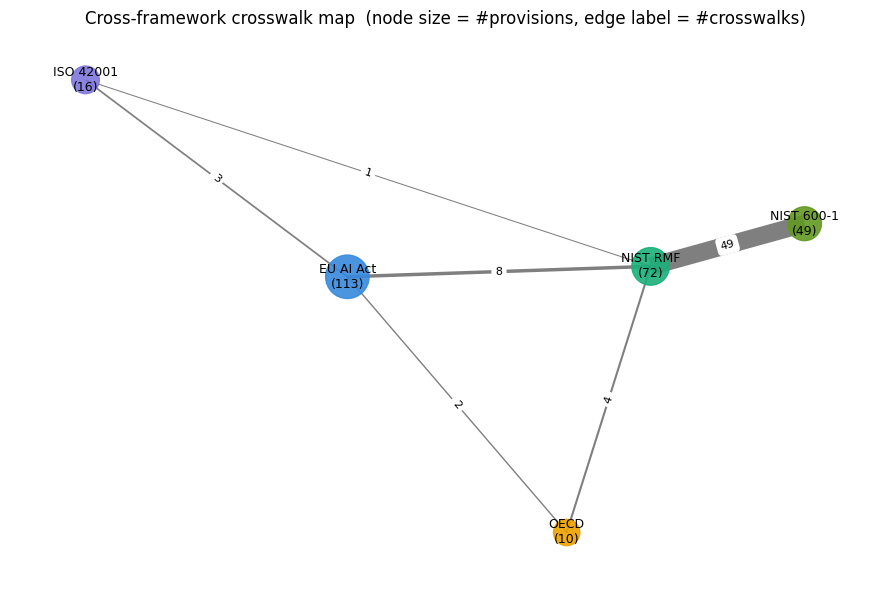

In [4]:
# The knowledge network at a glance: frameworks linked by the number of cited crosswalks.
_ = reg.framework_map()   # needs matplotlib

### Retrieval quality (does it find the right provision?)

A small labelled `issue → expected-provisions` set measures the data store — `hit` (any expected provision retrieved), `recall@k`, and `MRR`. This is how we tell whether a change to chunking or embeddings actually helps, rather than guessing. (Extend `regulus/eval.py` as coverage grows.)

In [5]:
# Retrieval quality on a small labelled eval set (hit-rate / recall@k / MRR).
demo.retrieval_report(reg, top_k=5)

/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: divide by zero encountered in matmul
  similarities = self.embeddings @ query_embedding[0]
/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: overflow encountered in matmul
  similarities = self.embeddings @ query_embedding[0]
/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: invalid value encountered in matmul
  similarities = self.embeddings @ query_embedding[0]


,issue,hit,recall@k,mrr,top-1
0,Real-time facial recognition in public spaces ...,1.0,1.000,1.000,"EU AI Act, Article 5 — Prohibited AI practices"
1,Our credit model was deployed without testing ...,1.0,1.000,0.250,"NIST AI 600-1 (GenAI Profile), MS-2.11 — MEASU..."
2,No post-deployment monitoring of a high-risk A...,1.0,0.500,1.000,"EU AI Act, Article 72 — Post-market monitoring..."
3,Users are not told they are interacting with a...,1.0,1.000,1.000,"EU AI Act, Article 50 — Transparency obligatio..."
4,No human oversight of the model's automated de...,1.0,1.000,1.000,"EU AI Act, Article 14 — Human oversight"
5,The high-risk system was not validated for acc...,1.0,1.000,1.000,"EU AI Act, Article 15 — Accuracy, robustness a..."
6,No logging or records of the AI system's opera...,1.0,1.000,1.000,"EU AI Act, Article 12 — Record-keeping"
7,There is no risk management system for our hig...,1.0,1.000,1.000,"EU AI Act, Article 9 — Risk management system"
8,We provide no instructions for use or transpar...,1.0,1.000,1.000,"EU AI Act, Article 13 — Transparency and provi..."
9,No fundamental rights impact assessment was pe...,1.0,1.000,1.000,"EU AI Act, Article 27 — Fundamental rights imp..."


## 4. Test scenarios

Realistic, multi-issue observations. Pick one (or write your own) to run through the system.

In [6]:
SCENARIOS = {
    'GenAI banking assistant': (
        'We launched a generative-AI assistant on our retail bank website that answers customer '
        'questions about mortgages, savings, and credit cards using retrieval over internal product '
        'documentation. In testing it occasionally states incorrect interest rates and invents '
        'promotional terms that do not exist, and it keeps no record of which documents it used for a '
        'given answer. It is live to the public and customers are not told they are talking to an AI.'
    ),
    'Hiring / resume screening': (
        'Our HR team uses a machine-learning model to screen and rank job applicants for shortlisting. '
        'It was trained on ten years of historical hiring decisions. We have not evaluated it for '
        'disparate impact across gender, age, or ethnicity, applicants are not informed that an '
        'automated system ranks them, and there is no human review before interview decisions. It is '
        'used for hiring in the EU.'
    ),
    'Credit underwriting model': (
        'We deployed a credit-underwriting model that approves or declines consumer loan applications. '
        'It went into production without documented validation of conceptual soundness, we did not test '
        'outcomes for fairness across protected classes, and there is no ongoing monitoring of '
        'performance or drift after deployment.'
    ),
}

scenario = SCENARIOS['GenAI banking assistant']
print(scenario)

We launched a generative-AI assistant on our retail bank website that answers customer questions about mortgages, savings, and credit cards using retrieval over internal product documentation. In testing it occasionally states incorrect interest rates and invents promotional terms that do not exist, and it keeps no record of which documents it used for a given answer. It is live to the public and customers are not told they are talking to an AI.


## 5. Assess a scenario

`reg.assess(scenario)` produces the full, **reproducible** assessment in three parts:

1. **Risks** in the scenario — the risk categories the retrieved provisions address.
2. **Applicable provisions** — the primary provisions (ranked), plus the *cited* related provisions in other frameworks (from the crosswalk graph).
3. **Interpretation & recommended mitigants** — an LLM narrates *why* each provision applies and recommends mitigants, **each grounded in a cited provision**.

**Reproducibility by design.** Parts 1–2 (the *facts* a reviewer relies on) are computed by code from a single retrieval pass over a fixed data store — identical on every run for the same scenario. Only part 3's wording may vary; it is labeled and runs at temperature 0 over the *exact same* retrieved provisions.

> With no API key, `assess()` still returns the complete deterministic core (parts 1–2) and marks part 3 as unavailable — so the pipeline is fully inspectable offline. For real generation: `pip install openai` and set `REGULUS_RETRIEVER=embedding` (keys are reused from your GKN `.env`).

In [7]:
reg.lookup(scenario, top_k=6)

/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: divide by zero encountered in matmul
  similarities = self.embeddings @ query_embedding[0]
/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: overflow encountered in matmul
  similarities = self.embeddings @ query_embedding[0]
/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: invalid value encountered in matmul
  similarities = self.embeddings @ query_embedding[0]


,provision,score,risks addressed,cross-framework references (cited)
0,"NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE...",0.502,"Explainable and interpretable, Fair — with har...","NIST AI RMF 1.0, MANAGE 3.2 — Manage function"
1,"NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASUR...",0.501,"Explainable and interpretable, Fair — with har...","NIST AI RMF 1.0, MEASURE 2.9 — Measure function"
2,"NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASUR...",0.497,"Safe, Secure and resilient, Valid and reliable","NIST AI RMF 1.0, MEASURE 2.5 — Measure function"
3,"NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE...",0.489,"Accountable and transparent, Secure and resili...","NIST AI RMF 1.0, MANAGE 4.1 — Manage function"
4,"NIST AI 600-1 (GenAI Profile), MG-4.2 — MANAGE...",0.485,"Fair — with harmful bias managed, Valid and re...","NIST AI RMF 1.0, MANAGE 4.2 — Manage function"
5,"NIST AI 600-1 (GenAI Profile), MS-2.10 — MEASU...",0.478,Fair — with harmful bias managed,"NIST AI RMF 1.0, MEASURE 2.10 — Measure function"


In [8]:
_ = reg.assess(scenario)

/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: divide by zero encountered in matmul
  similarities = self.embeddings @ query_embedding[0]
/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: overflow encountered in matmul
  similarities = self.embeddings @ query_embedding[0]
/Users/minwu/Documents/GenAI/geometric_knowledge_network/src/geometric_knowledge_network/vector_store.py:181: RuntimeWarning: invalid value encountered in matmul
  similarities = self.embeddings @ query_embedding[0]


### Regulus — interpretation
**System under review:** A generative-AI customer-service assistant for a retail bank. It answers customer questions about mortgages, savings, and credit cards by retrieving from internal product documentation, and is live to the public.

**Issue:** We launched a generative-AI assistant on our retail bank website that answers customer questions about mortgages, savings, and credit cards using retrieval over internal product documentation. In testing it occasionally states incorrect interest rates and invents promotional terms that do not exist, and it keeps no record of which documents it used for a given answer. It is live to the public and customers are not told they are talking to an AI.

## 1. Assessment

This issue primarily implicates **validity/reliability, transparency/accountability, and explainability** for a public-facing generative-AI banking assistant that is producing incorrect or invented product terms and lacks records of what source documents supported each answer. The retrieved provisions point to the need to **measure and document confabulation/explanation results**, avoid relying on anecdotal testing, and **monitor and report** on system performance and improvements over time (NIST AI 600-1 MS-2.9, MS-2.5, MG-4.1, MG-4.2, MG-3.2).

## 2. Applicable provisions

### NIST AI 600-1 (GenAI Profile), **MS-2.9 — MEASURE 2.9**
**Why it applies:** The assistant is occasionally stating incorrect interest rates and inventing promotional terms, which is directly relevant to the provision’s reference to **confabulation** and to applying and documenting explanation results. The absence of records showing which documents were used for a given answer also makes the “apply and document” aspect especially relevant (NIST AI 600-1 MS-2.9).  
**Risks addressed:** Explainable and interpretable; Fair — with harmful bias managed; Privacy-enhanced (NIST AI 600-1 MS-2.9).

### NIST AI 600-1 (GenAI Profile), **MS-2.5 — MEASURE 2.5**
**Why it applies:** You note the issue was found “in testing,” but this provision says to **avoid extrapolating** system performance or capabilities from **narrow, non-systematic, and anecdotal assessments**. For a live public banking assistant, this supports more systematic evaluation of confabulation and the extent of human domain knowledge in the configuration (NIST AI 600-1 MS-2.5).  
**Risks addressed:** Safe, Secure and resilient; Valid and reliable (NIST AI 600-1 MS-2.5).

### NIST AI 600-1 (GenAI Profile), **MG-3.2 — MANAGE 3.2**
**Why it applies:** The provision calls for applying **explainable AI techniques** as part of ongoing activities. That is relevant where the system cannot show what information or model behavior led to an answer, especially when the answer contains inaccurate banking product information (NIST AI 600-1 MG-3.2).  
**Risks addressed:** Explainable and interpretable; Fair — with harmful bias managed; Privacy-enhanced (NIST AI 600-1 MG-3.2).

### NIST AI 600-1 (GenAI Profile), **MG-4.1 — MANAGE 4.1**
**Why it applies:** This provision calls for sharing **transparency reports** with internal and external stakeholders detailing steps taken to update the GAI system to enhance transparency and accountability. That is relevant to a public-facing assistant with known confabulation issues and no answer-level source record, because the issue concerns both transparency and accountability for remediation (NIST AI 600-1 MG-4.1).  
**Risks addressed:** Accountable and transparent; Secure and resilient; Valid and reliable (NIST AI 600-1 MG-4.1).

### NIST AI 600-1 (GenAI Profile), **MG-4.2 — MANAGE 4.2**
**Why it applies:** The provision calls for **regular monitoring** of GAI systems and reports on performance, feedback, and improvements made. That fits a live public deployment where incorrect rates and invented terms create an ongoing need to monitor outputs, collect feedback, and track corrective actions (NIST AI 600-1 MG-4.2).  
**Risks addressed:** Fair — with harmful bias managed; Valid and reliable (NIST AI 600-1 MG-4.2).

## 3. Cross-framework view

Each cited GenAI Profile provision is linked in the context to the corresponding **NIST AI RMF 1.0** subcategory as **related guidance**, with the note that this is an **authoritative structural mapping** because NIST AI 600-1 keys its suggested actions to AI RMF subcategories.

- **MS-2.9** maps to **NIST AI RMF 1.0, MEASURE 2.9** as related guidance, supporting documentation of explanation results and confabulation-related measurement (**authoritative structural mapping**) (NIST AI 600-1 MS-2.9).
- **MS-2.5** maps to **NIST AI RMF 1.0, MEASURE 2.5** as related guidance, supporting systematic rather than anecdotal assessment of performance/capabilities (**authoritative structural mapping**) (NIST AI 600-1 MS-2.5).
- **MG-3.2** maps to **NIST AI RMF 1.0, MANAGE 3.2** as related guidance, supporting use of explainability techniques in ongoing management (**authoritative structural mapping**) (NIST AI 600-1 MG-3.2).
- **MG-4.1** maps to **NIST AI RMF 1.0, MANAGE 4.1** as related guidance, supporting transparency and accountability reporting (**authoritative structural mapping**) (NIST AI 600-1 MG-4.1).
- **MG-4.2** maps to **NIST AI RMF 1.0, MANAGE 4.2** as related guidance, supporting regular monitoring and reporting on performance, feedback, and improvements (**authoritative structural mapping**) (NIST AI 600-1 MG-4.2).

## 4. Suggested next steps

1. **Document and measure confabulation explicitly** for incorrect rates, invented promotions, and similar answer failures, using a structured evaluation rather than relying on ad hoc testing results (NIST AI 600-1 MS-2.9, MS-2.5).

2. **Implement answer-level documentation of explanation results and supporting evidence** so the organization can determine what drove a given response and retain records of the basis for outputs, consistent with the provisions’ emphasis on applying and documenting explanation results and XAI techniques (NIST AI 600-1 MS-2.9, MG-3.2).

3. **Use explainability techniques in ongoing control activities** to analyze why the model is producing unsupported product terms or incorrect rates, and use those findings to guide remediation (NIST AI 600-1 MG-3.2).

4. **Establish regular monitoring and reporting** for this live public system, including output performance, user feedback, identified confabulation cases, and improvements made after remediation (NIST AI 600-1 MG-4.2).

5. **Prepare transparency reporting for stakeholders** that explains the known issues, what updates are being made to improve transparency/accountability, and how reliability is being improved over time (NIST AI 600-1 MG-4.1).

6. **Reassess whether current testing is sufficiently systematic** before treating the assistant as reliable for public banking-product answers, since

## 6. Visualize the regulatory neighborhood

The diagram is the local map of one scenario in the knowledge network — a picture of the same facts from `assess()`:

- **Bold-outlined squares** = the *direct-hit* provisions (Part 2's primary provisions). These are what the scenario most directly implicates.
- **Plain squares** = the *cited crosswalk* provisions they link to, colored by framework — the same regulatory concern expressed in other standards. This is Regulus's differentiator: it shows how frameworks connect, with curated citations, not just a flat list.
- **Grey circles** = the *risk categories* those provisions address (Part 1's risks).

**What to take from it:** which provision is the anchor, which other frameworks say the same thing (so a control satisfies several at once), and which risks are in play. An isolated square with few links is a narrow, single-framework issue; a densely linked cluster is a cross-cutting one worth prioritizing.

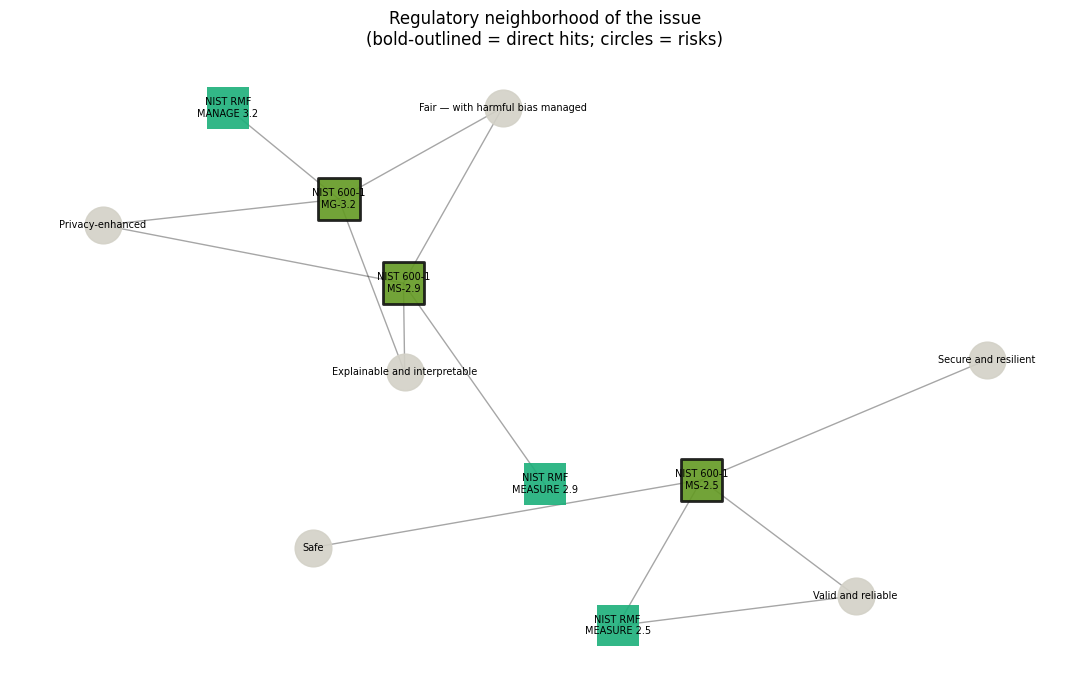

In [9]:
_ = reg.visualize(scenario, top_k=3)   # needs matplotlib

## What's next

- **Sharper retrieval** — set `RETRIEVER = 'embedding'` above for embedding-quality context.
- **Evidence paths** — return the full trail (issue → provision → crosswalk → provision) via GKN's path explainer.
- **Measure the claim** — benchmark the graph-grounded answer against a flat-RAG baseline.
- **Interface** — a "submit an issue" web UI.

**Extend Regulus:** add crosswalk rows or frameworks under `data/`, or swap the seed crosswalks for authoritative mappings.